In [2]:
import jax 
import jax.numpy as jnp
import time
import matplotlib.pyplot as plt

In [3]:
def Gauss_fun(mu, sigma):

    f = lambda x: (
        1.0 / (sigma*jnp.sqrt(2.0*jnp.pi)) *
        jnp.exp( -0.5*(x-mu)**2 / (sigma**2) )
    )

    return f

In [4]:
σ = jnp.sqrt(0.2)
μ = 0.0

Gaussian = Gauss_fun(μ, σ)

x_fun = jnp.linspace(-5.0, 5.0, 10000)
val = jax.vmap(Gaussian)(x_fun)

In [5]:
start_time = time.time()

fx = jax.grad(Gaussian)
fxx = jax.grad(fx)
fxxx = jax.grad(fxx)

val_1st = jax.vmap(Gaussian)(x_fun)
val_2nd = jax.vmap(Gaussian)(x_fun)
val_3rd = jax.vmap(Gaussian)(x_fun)


print(f"- Time required for program execution was: {time.time() - start_time}")

- Time required for program execution was: 0.03075861930847168


In [6]:
import numpy as np

In [7]:
x_hat = np.linspace(-3.0,3.0,100)
def fhat(x):
    val = np.where( (abs(x) < np.pi/2.0), np.pi/2.0 - abs(x), 0.0 )
    return val


In [34]:
def Fourier(x, f, m):

    L = (x[-1] - x[0]) / 2.0     # half-length (from -L to L)
    dx = x[1] - x[0]
    w = np.pi / L               

    # A0 term
    A0 = np.sum(f(x)) * dx
    res = A0 / (2.0 * L)

    # modes k = 1..m
    for k in range(1, m+1):
        A = np.sum(f(x) * np.cos(k * w * x)) * dx / L
        B = np.sum(f(x) * np.sin(k * w * x)) * dx / L

        res += A*np.cos(k*w*x) + B*np.sin(k*w*x)

    return res


In [35]:
m = 10
Fhat = Fourier(x_hat, fhat, m)

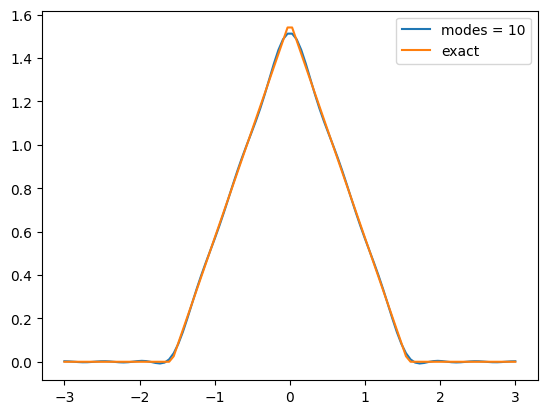

In [36]:
plt.plot(x_hat, Fhat, label = f"modes = {m}")
plt.plot(x_hat, fhat(x_hat), label = "exact")
plt.legend()
plt.show()

In [46]:
import jax
import jax.numpy as jnp
import optax 
import matplotlib.pyplot as plt
from jax import value_and_grad
import equinox as eqx

In [97]:
def Runge(x):
    val = 1.0/(1.0+25*x**2)
    return val

def fhat(x):
    val = np.where( (abs(x) < np.pi/2.0), np.pi/2.0 - abs(x), 0.0 )
    return val

def first_branch(x):
    val = 0.0
    for k in range(6):
        val = jnp.sin(k*x) + val
    return val + 5.0

def osc_function(x):
    y = jnp.zeros(len(x))
    for i in range(len(x)):
        if x[i] < 0.0:
            y = y.at[i].set( first_branch(x[i]) )
        else:
            y = y.at[i].set( jnp.cos(10.0*x[i]) )
    return y

In [156]:
seed = 420
LR = 0.001

xrunge = jnp.linspace(-1.0,1.0, 500)
yrunge = Runge(xrunge)
x_hat = jnp.linspace(-jnp.pi/2.0,jnp.pi/2,500)
yhat = fhat(x_hat)
xosc = jnp.linspace(-jnp.pi,jnp.pi, 500)
yosc = osc_function(xosc)

xrunge = xrunge.reshape(len(xrunge), 1)
yrunge = yrunge.reshape(len(yrunge), 1)
x_hat = x_hat.reshape(len(x_hat), 1)
yhat - yhat.reshape(len(yhat), 1)
xosc = xosc.reshape(len(xosc), 1)
yosc = yosc.reshape(len(yosc), 1)

key = jax.random.PRNGKey(seed)
key_data, w_key, b_key = jax.random.split(key, num=3)

x_normalizer = jnp.max(x_hat)
y_normalizer = jnp.max(yhat)


In [157]:
model = eqx.nn.MLP(
    in_size = 1,
    out_size = 1,
    width_size = 100,
    depth = 4,
    activation = jnp.sin,
    key = w_key
)

In [158]:
def compute_loss(m, x_in, y_exact):

    y_pred = jax.vmap(m)(x_in)
    delta = y_exact - y_pred
    
    return 0.5 * jnp.mean(delta**2)



In [159]:
optim = optax.adam(LR)
optim_state = optim.init(eqx.filter(model, eqx.is_array))

In [160]:
@eqx.filter_jit
def make_step(m, x_in, y_exact, opt_state):

    loss, grads = eqx.filter_value_and_grad(compute_loss)(m, x_in, y_exact)
    updates, opt_state = optim.update(grads, opt_state, m)
    m = eqx.apply_updates(m, updates)

    return m, opt_state, loss
    

In [161]:
runge_hist_loss = []
N_EPOCHS = 30_000
for epoch in range(N_EPOCHS):

    model, optim_state, loss_eqx = make_step(model, x_hat, yhat, optim_state)
    runge_hist_loss.append(loss_eqx)
    if epoch % 5000 == 0:
        print(f" Epochs: {epoch}, loss = {loss_eqx}")
    

 Epochs: 0, loss = 0.5618862509727478
 Epochs: 5000, loss = 0.10321930795907974
 Epochs: 10000, loss = 0.10321968793869019
 Epochs: 15000, loss = 0.10321919620037079
 Epochs: 20000, loss = 0.10321921855211258
 Epochs: 25000, loss = 0.10321920365095139


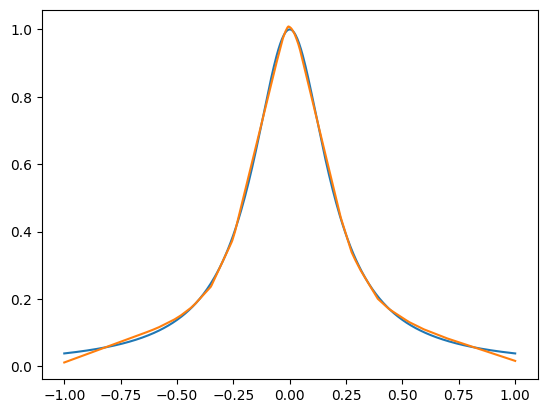

In [104]:
plt.plot(xrunge, yrunge)
plt.plot(xrunge, jax.vmap(model)(xrunge))

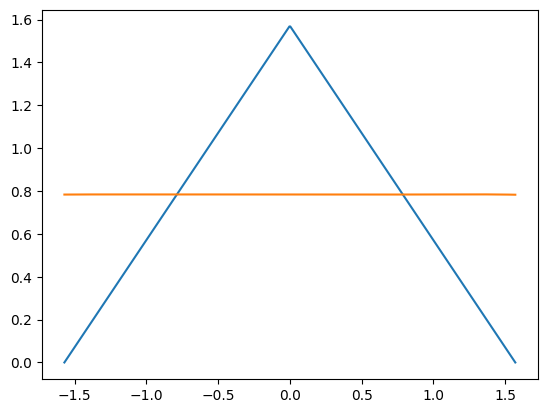

In [162]:
plt.plot(x_hat, yhat)
plt.plot(x_hat, jax.vmap(model)(x_hat))

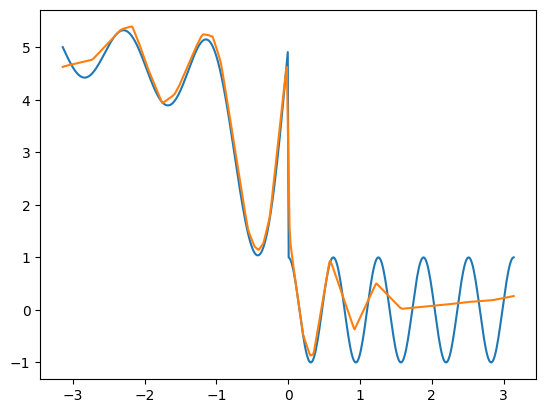

In [96]:
plt.plot(xosc, yosc)
plt.plot(xosc, jax.vmap(model)(xosc))